# Deep Learning to reconstruct an image from its fMRI response

# Description:


 # Stage 1: Dataset
 (Dataset description) provenance, configuration

 Stimuli images can be be obtained thnaks to this link:

1. Folders and setup

In [ ]:
#!pip install if dependencies not directly available

In [ ]:
import os
import requests
from tqdm import tqdm
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
project = '/content/image_reconstruction'
fMRI = '/content/image_reconstruction/fMRI'
images = '/content/image_reconstruction/images'

for dir in [project,
          fMRI,
          images,
          os.path.join(images, 'training'),
          os.path.join(images, 'test')]:
    os.makedirs(dir, exist_ok=True)

print('Folders :')
print(f'  {project}')
print(f'  {fMRI}')
print(f'  {images}')

Folders :
  /content/image_reconstruction
  /content/image_reconstruction/fMRI
  /content/image_reconstruction/images


2. Download fMRI data


Subject1.mat is in HDF5 v7.3 format.
 It contains:

- dataSet with shape (4471, 3450) and float64 dtype.
- A metaData group containing:
  -  description dataset with shape (21, 1) and object dtype.
  - key dataset with shape (21, 1) and object dtype.
  - value dataset with shape (4471, 21) and float64 dtype.

Source : figshare via S3 AWS (URL obtained through https://github.com/KamitaniLab/GenericObjectDecoding)

In [ ]:
MAT_URL  = 'https://s3-eu-west-1.amazonaws.com/pfigshare-u-files/13663487/Subject1.mat'
MAT_PATH = os.path.join(fMRI, 'Subject1.mat')

if os.path.exists(MAT_PATH):
    print(f'Subject1 already downloaded')
else:
    print('Downloading Subject1.mat...')
    r = requests.get(
        MAT_URL, stream=True,
        headers={'User-Agent': 'Mozilla/5.0'}
    )
    total = int(r.headers.get('content-length', 0))
    with open(MAT_PATH, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True) as bar:
        for chunk in r.iter_content(8192):
            f.write(chunk)
            bar.update(len(chunk))
    print(f'\n Subject1 downloaded :{os.path.getsize(MAT_PATH)/1e6:.0f} MB')

100%|██████████| 120M/120M [00:06<00:00, 18.4MB/s]


 Subject1 downloaded :120 MB


3. Extract fMRI data

In [ ]:
f = h5py.File(MAT_PATH, 'r')
data = f['dataSet'][:]
meta = f['metaData/value'][:]
key_refs = f['metaData/key'][:].flatten()
keys = [''.join(chr(c[0]) for c in f[ref][:]) for ref in key_refs]

print(f'dataSet shape  : {data.shape}')
print(f'metaData shape : {meta.shape}')
print(f'Columns in metaData  : {keys}')



dataSet shape  : (4471, 3450)
metaData shape : (4471, 21)
Columns in metaData  : ['DataType', 'Run', 'Label', 'VoxelData', 'voxel_x', 'voxel_y', 'voxel_z', 'VolInds', 'ROI_V1', 'ROI_V2', 'ROI_V3', 'ROI_V4', 'ROI_LOC', 'ROI_FFA', 'ROI_PPA', 'ROI_LVC', 'ROI_HVC', 'ROI_VC', 'stimulus_id', 'category_index', 'image_index']


In [ ]:
# data contains lines with voxels and lines with metadata
voxeldata_col = keys.index('VoxelData')
is_voxel = meta[:, voxeldata_col] == 1.0
is_other = ~is_voxel

print(f'True voxels     : {is_voxel.sum()}')
print(f'Metadata lines : {is_other.sum()}')

other_indices = np.where(is_other)[0]
for i in other_indices:
  row      = data[i, :]
  meta_row = meta[i, :]
  active   = [keys[k] for k in range(len(keys)) if meta_row[k] == 1.0]
  unique   = np.unique(row[~np.isnan(row)])
  print(f'  line {i}, meta={active}')

True voxels     : 4466
Metadata lines : 5
  line 0, meta=['DataType']
  line 1, meta=['Run']
  line 4468, meta=['Label', 'stimulus_id']
  line 4469, meta=['Label', 'category_index']
  line 4470, meta=['Label', 'image_index']


In [ ]:
fmri_all = data[is_voxel, :].T.astype(np.float32)  # (3450, 4466)
datatype = data[0,    :].astype(int) # 1=train, 2=test, 3=imagery
run = data[1,    :].astype(int) # run number
image_index = data[4470, :] # index image

#test and train
mask_train = datatype == 1
mask_test = datatype == 2

fmri_train = fmri_all[mask_train]
fmri_test_raw = fmri_all[mask_test]
img_idx_train = image_index[mask_train]
img_idx_test = image_index[mask_test]

# for the test images, each image was seen 35 times
# so we can compute the average fMRI response for each image
unique_test_imgs = np.unique(img_idx_test[~np.isnan(img_idx_test)]).astype(int)
fmri_test = np.array([fmri_test_raw[img_idx_test == img].mean(axis=0) for img in unique_test_imgs])

print('Data :')
print(f'  fmri_train : {fmri_train.shape} ({mask_train.sum()} trials)')
print(f'  fmri_test_raw : {fmri_test_raw.shape} ({mask_test.sum()} trials)')
print(f'  fmri_test : {fmri_test.shape} (50 images x {35} averaged)')

Data :
  fmri_train : (1200, 4466) (1200 trials)
  fmri_test_raw : (1750, 4466) (1750 trials)
  fmri_test : (50, 4466) (50 images x 35 averaged)


In [ ]:
# Clip outliers in fMRI
CLIP_VAL = 20.0

fmri_train    = np.clip(fmri_train, -CLIP_VAL, CLIP_VAL).astype(np.float32)
fmri_test     = np.clip(fmri_test, -CLIP_VAL, CLIP_VAL).astype(np.float32)
fmri_test_raw = np.clip(fmri_test_raw, -CLIP_VAL, CLIP_VAL).astype(np.float32)

print(f'Apres clipping :')
print(f'  fmri_train mean : {fmri_train.mean():.3f}')
print(f'  fmri_train std : {fmri_train.std():.3f}')
print(f'  fmri_train max : {fmri_train.max():.3f}')
print(f'  % voxels clipped : {(np.abs(fmri_train) == CLIP_VAL).mean()*100:.2f}%')

Apres clipping :
  fmri_train mean : 0.034
  fmri_train std  : 3.815
  fmri_train max  : 20.000
  % voxels clippes : 0.50%


In [ ]:
# Extract ROI for later study
roi_names = ['ROI_V1', 'ROI_V2', 'ROI_V3', 'ROI_V4', 'ROI_LOC', 'ROI_FFA', 'ROI_PPA', 'ROI_LVC', 'ROI_HVC', 'ROI_VC']

roi_masks = {}
for roi in roi_names:
    if roi in keys:
        col_idx = keys.index(roi)
        mask = meta[is_voxel, col_idx] == 1.0
        roi_masks[roi] = mask
        print(f'  {roi:10s} : {mask.sum():} voxels')

  ROI_V1     : 1004 voxels
  ROI_V2     : 1018 voxels
  ROI_V3     : 759 voxels
  ROI_V4     : 740 voxels
  ROI_LOC    : 540 voxels
  ROI_FFA    : 568 voxels
  ROI_PPA    : 356 voxels
  ROI_LVC    : 2281 voxels
  ROI_HVC    : 2049 voxels
  ROI_VC     : 4466 voxels


4. Download stimulus

Due to copyright reasons on ImageNet, the images used as stimuli cannot be directly provided, but a zip file can be requested with the following form: https://forms.gle/ujvA34948Xg49jdn9

The following cell allows to download and unzip the folder from your google drive (easy when using google colab).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os, getpass

ZIP_PATH = '/content/drive/MyDrive/images_passwd.zip'

password = getpass.getpass('zip password : ')

EXTRACT_DIR = '/content/image_reconstruction'

print(f'Extraction of {ZIP_PATH}...')
try:
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR, pwd=password.encode('utf-8'))
    print('Success')
except RuntimeError as e:
    print(f'Erreur : {e}')
    print('Verify password')

print('\nExtracted :')
for root, dirs, files in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, '').count(os.sep)
    indent = '  ' * level
    n = len(files)
    print(f'{indent}{os.path.basename(root)}/ ({n} files)')

Mounted at /content/drive
zip password : ··········
Extraction of /content/drive/MyDrive/images_passwd.zip...
Success

Extracted :
image_reconstruction/ (0 files)
  images/ (2 files)
    test/ (50 files)
    training/ (1200 files)
  fMRI/ (1 files)


In [ ]:
test_dir = os.path.join(EXTRACT_DIR, 'images', 'test')
train_dir = os.path.join(EXTRACT_DIR, 'images', 'training')
test_id_csv = os.path.join(EXTRACT_DIR, 'images', 'image_test_id.csv')
train_id_csv = os.path.join(EXTRACT_DIR, 'images', 'image_training_id.csv')

ids_train = pd.read_csv(train_id_csv, header=None, names=['img_idx', 'filename'])
ids_test = pd.read_csv(test_id_csv,  header=None, names=['img_idx', 'filename'])

print(f'\nIDs train : {len(ids_train)}')
print(ids_train.head(3))
print(f'\nIDs test  : {len(ids_test)}')
print(ids_test.head(3))


IDs train : 1200
        img_idx              filename
0  1.518878e+06  n01518878_10042.JPEG
1  1.518878e+06  n01518878_12028.JPEG
2  1.518878e+06  n01518878_14075.JPEG

IDs test  : 50
        img_idx              filename
0  1.443537e+06  n01443537_22563.JPEG
1  1.621127e+06  n01621127_19020.JPEG
2  1.677366e+06  n01677366_18182.JPEG


5. Building the fMRI/image pairs

In [ ]:
# image_index in the fMRI = position in the CSV

train_idx_to_path = {}
for i, row in ids_train.iterrows():
    position = i + 1
    filename = str(row['filename']).strip()
    path = os.path.join(train_dir, filename)
    if os.path.exists(path):
        train_idx_to_path[position] = path

test_idx_to_path = {}
for i, row in ids_test.iterrows():
    position = i + 1
    filename = str(row['filename']).strip()
    path = os.path.join(test_dir, filename)
    if os.path.exists(path):
        test_idx_to_path[position] = path

print(f'Train : {len(train_idx_to_path)}/1200')
print(f'Test  : {len(test_idx_to_path)}/50')

Train : 1200/1200
Test  : 50/50


In [ ]:
def build_pairs(fmri_data, img_indices, idx_to_path):
    pairs = []
    for trial_idx, img_pos in enumerate(img_indices):
        img_pos = int(img_pos)
        if img_pos in idx_to_path:
            pairs.append({'trial_idx': trial_idx, 'img_pos': img_pos,'fmri': fmri_data[trial_idx],'img_path': idx_to_path[img_pos],})
    return pairs

pairs_train = build_pairs(fmri_train, img_idx_train, train_idx_to_path)
pairs_test  = build_pairs(fmri_test,  unique_test_imgs, test_idx_to_path)

print(f'Built pairs :')
print(f'  Train : {len(pairs_train)}')
print(f'  Test  : {len(pairs_test)}')

Built pairs :
  Train : 1200
  Test  : 50


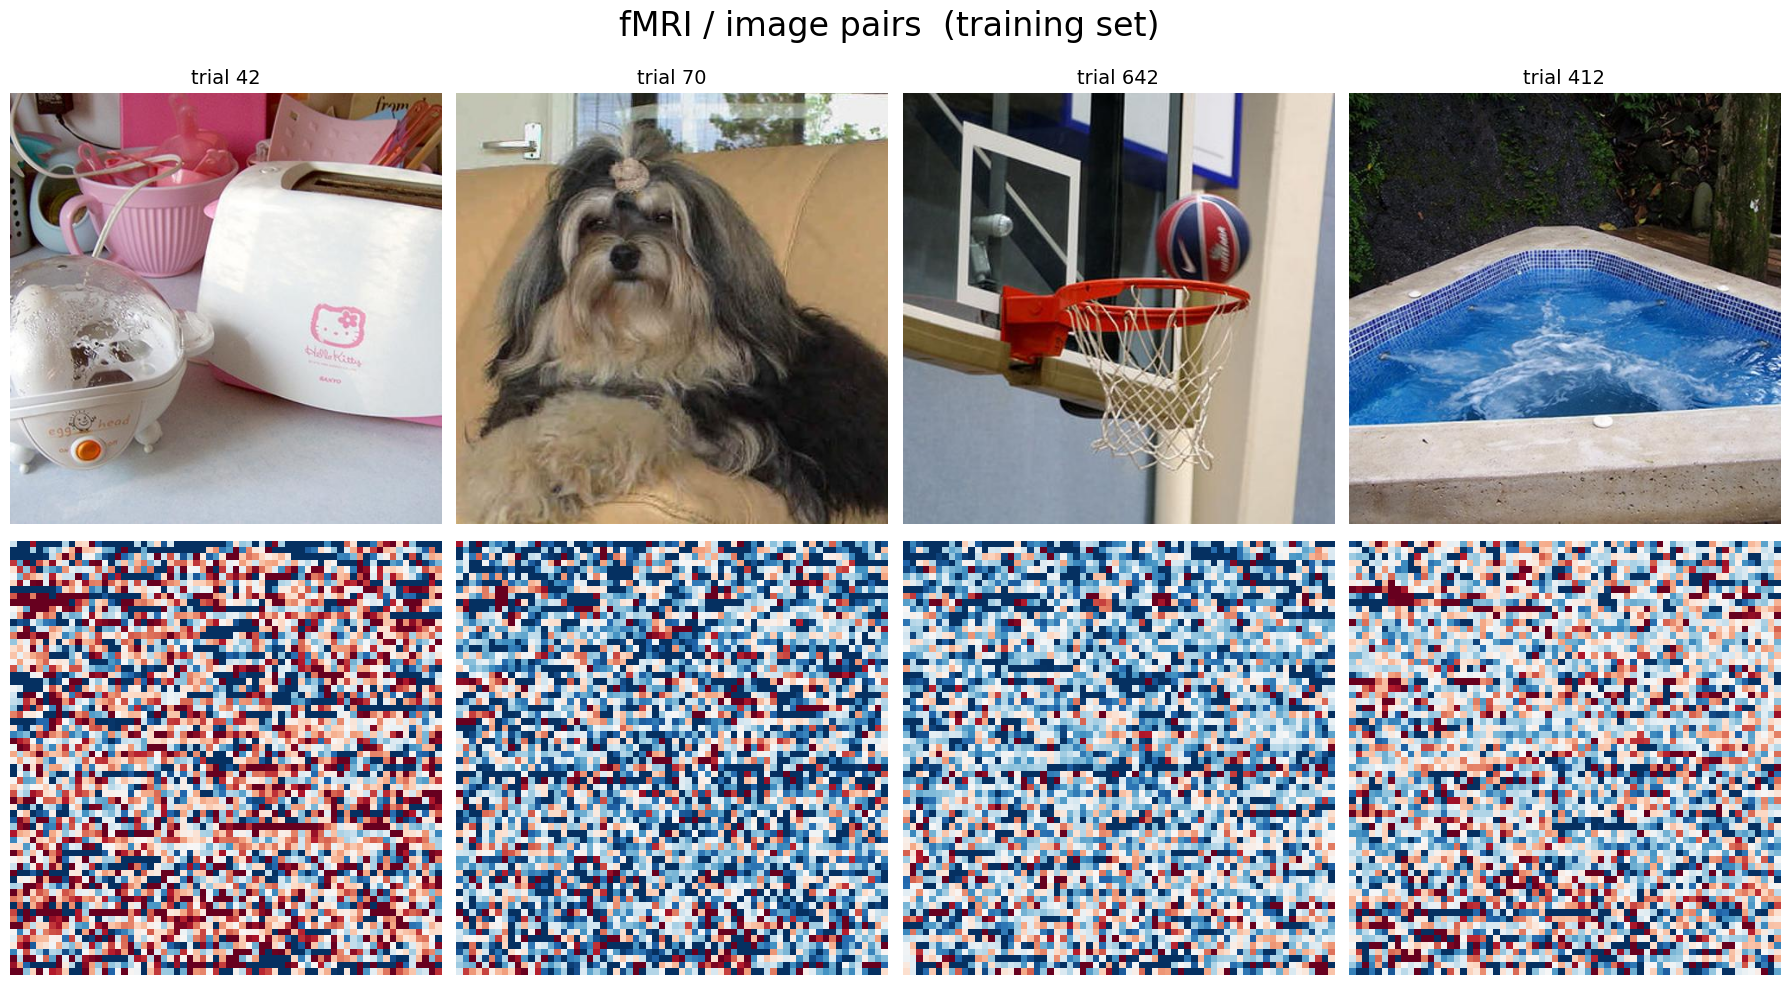

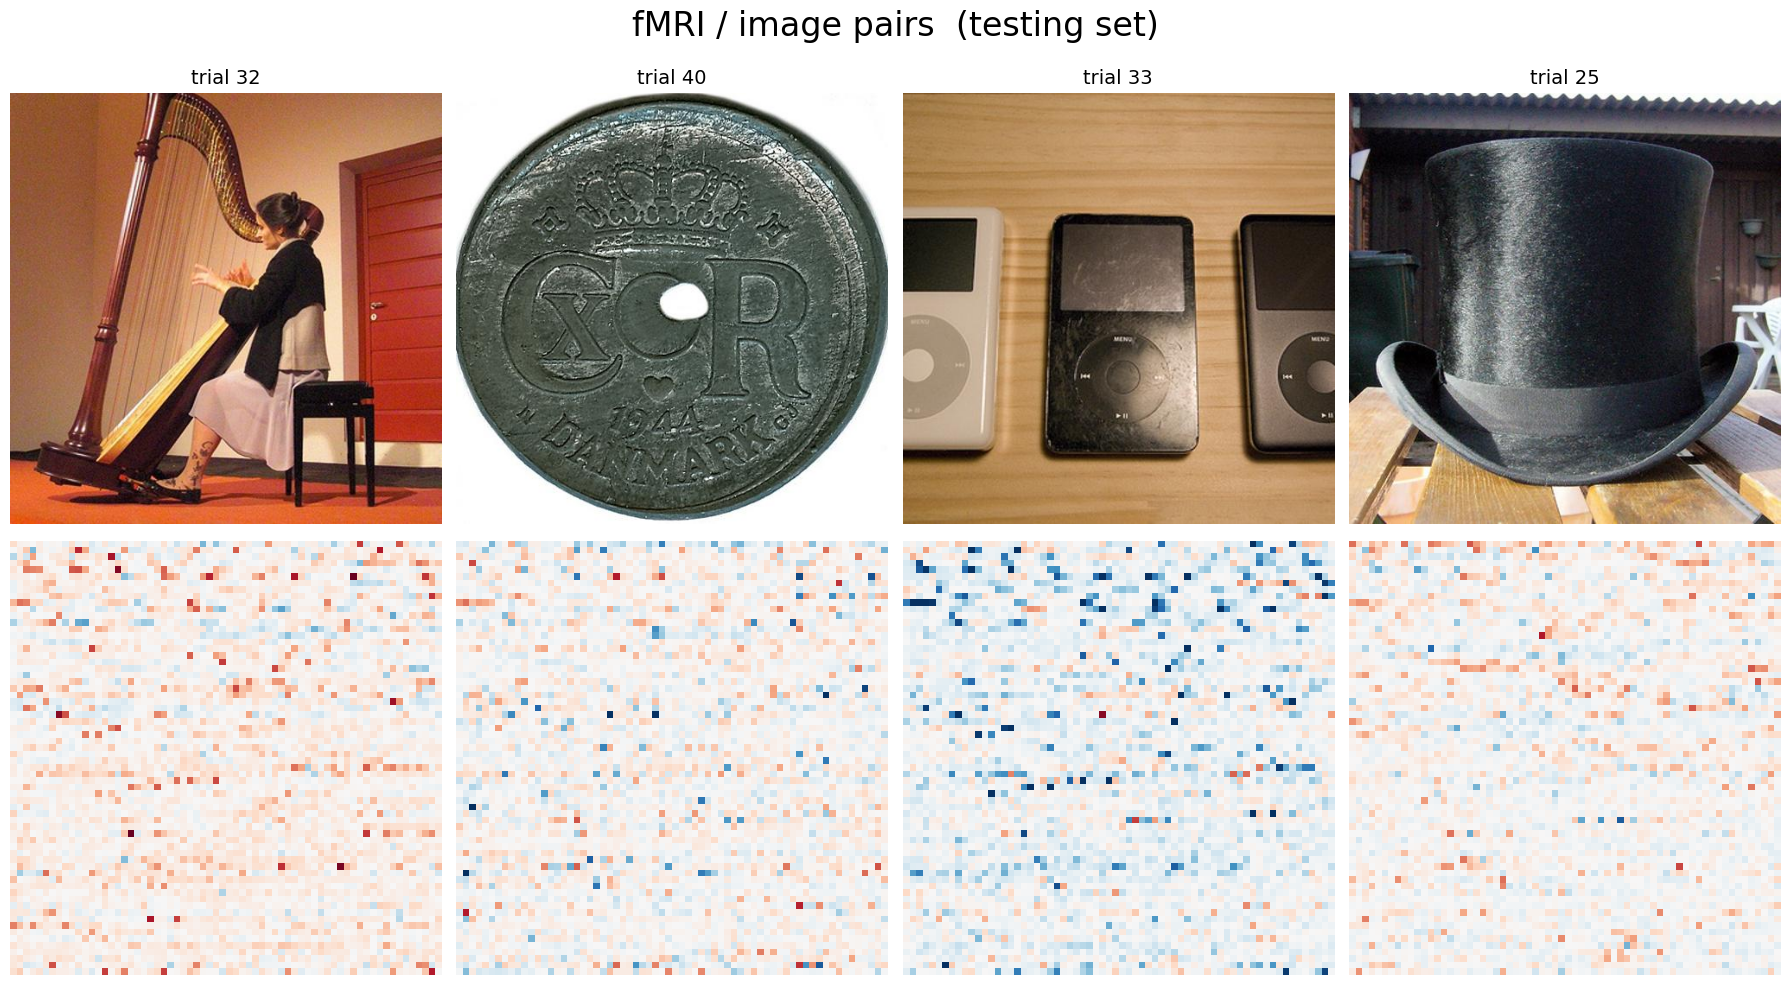

In [ ]:
# Display some fMRI/image pairs
import random as rand
indices = rand.sample(range(len(pairs_train)), 4)
pairs_display = [pairs_train[i] for i in indices]

#training set
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('fMRI / image pairs  (training set) \n', fontsize=24)

for c, pair in enumerate(pairs_display):
  #img
  img = Image.open(pair['img_path']).convert('RGB')
  axes[0, c].imshow(img)
  axes[0, c].set_title(f'trial {pair["trial_idx"]}', fontsize=14)
  axes[0, c].axis('off')

  #fMRI
  fmri = pair['fmri']
  n = int(np.sqrt(fmri.shape[0]))
  fmri = fmri[:n*n]
  fmri = fmri.reshape(n, n)
  axes[1, c].imshow(fmri, cmap='RdBu_r', aspect='auto', vmin=-3, vmax=3)
  axes[1, c].set_title(' ', fontsize=14)
  axes[1, c].axis('off')

plt.tight_layout()
plt.show()

print("\n")
#testing set

indices = rand.sample(range(len(pairs_test)), 4)
pairs_display = [pairs_test[i] for i in indices]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('fMRI / image pairs  (testing set)\n', fontsize=24)

for c, pair in enumerate(pairs_display):
  #img
  img = Image.open(pair['img_path']).convert('RGB')
  axes[0, c].imshow(img)
  axes[0, c].set_title(f'trial {pair["trial_idx"]}', fontsize=14)
  axes[0, c].axis('off')

  #fMRI
  fmri = pair['fmri']
  n = int(np.sqrt(fmri.shape[0]))
  fmri = fmri[:n*n]
  fmri = fmri.reshape(n, n)
  axes[1, c].imshow(fmri, cmap='RdBu_r', aspect='auto', vmin=-3, vmax=3)
  axes[1, c].set_title(' ', fontsize=14)
  axes[1, c].axis('off')

plt.tight_layout()
plt.show()

#Stage 2: Encoder-Decoder

The architectures of the encoder and the decoder are based on the paper :

"From voxels to pixels and back: Self-supervision in
natural-image reconstruction from fMRI" (Beliy et al., 2019)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import torchvision.transforms as T
import torchvision.models as models
import urllib.request, zipfile

The training of the models require a gpu for acceptable computing time.

In [ ]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')

Device : cuda


1. Creation of the training and testing datasets

Three datasets for training have to be created:
- the supervised dataset: pairs of fMRIs and their corresponding image (used to train both the encoder and the decoder)
- the image dataset for unsupervised training (E-D architecture): images from TinyImageNet
- the fMRI dataset for unsupervised training (D-E architecture): fMRIs from the testing set (no data leackage since the corresponding images are never seen)

In [ ]:
UNLABELED_DIR = '/content/image_reconstruction/unlabled'
os.makedirs(UNLABELED_DIR, exist_ok=True)

TINY_URL  = 'http://cs231n.stanford.edu/tiny-imagenet-200.zip'
TINY_ZIP  = os.path.join(UNLABELED_DIR, 'tiny-imagenet-200.zip')
TINY_DIR  = os.path.join(UNLABELED_DIR, 'tiny-imagenet-200')

if os.path.exists(TINY_DIR) and len(os.listdir(TINY_DIR)) > 0:
    print('TinyImageNet deja present')
else:
    print('Downloading TinyImageNet...')
    import requests
    r = requests.get(TINY_URL, stream=True)
    total = int(r.headers.get('content-length', 0))
    with open(TINY_ZIP, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True) as bar:
        for chunk in r.iter_content(8192):
            f.write(chunk)
            bar.update(len(chunk))
    print('Extraction...')
    with zipfile.ZipFile(TINY_ZIP, 'r') as z:
        z.extractall(UNLABELED_DIR)
    print('OK')

unlabeled_paths = []
for root, dirs, files in os.walk(TINY_DIR):
    for fname in files:
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            unlabeled_paths.append(os.path.join(root, fname))

print(f'Unlabled images available : {len(unlabeled_paths)}')

100%|██████████| 248M/248M [00:04<00:00, 52.8MB/s]


Extraction...
OK
Unlabled images available : 120000


In [ ]:
IMG_SIZE = 112

transform_train = T.Compose([
    T.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
    T.RandomCrop((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

transform_test = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

# Denormalisation for visualisation
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor.cpu() * std + mean).clamp(0, 1)


class PairedDataset(Dataset):
    def __init__(self, pairs, transform):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, i):
        pair = self.pairs[i]
        img = Image.open(pair['img_path']).convert('RGB')
        return self.transform(img), torch.FloatTensor(pair['fmri'])


class UnlabeledImageDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths     = paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        try:
            img = Image.open(self.paths[i]).convert('RGB')
            return self.transform(img)
        except Exception:
            return torch.zeros(3, IMG_SIZE, IMG_SIZE)


class FMRIDataset(Dataset):
    def __init__(self, fmri_data):
        self.fmri = fmri_data

    def __len__(self):
        return len(self.fmri)

    def __getitem__(self, i):
        return torch.FloatTensor(self.fmri[i])


dataset_train = PairedDataset(pairs_train, transform_train)
dataset_test_vis = PairedDataset(pairs_test, transform_test)
dataset_unlabeled = UnlabeledImageDataset(unlabeled_paths, transform_train)
dataset_fmri_test = FMRIDataset(fmri_test)
#dataset_fmri_test_raw = FMRIDataset(fmri_test_raw)

print(f'Dataset train : {len(dataset_train)} pairs')
print(f'Dataset test : {len(dataset_test_vis)} pairs')
print(f'Dataset unlabeled : {len(dataset_unlabeled)} images')
print(f'Dataset fMRI test : {len(dataset_fmri_test)} vectors')

Dataset train : 1200 pairs
Dataset test : 50 pairs
Dataset unlabeled : 120000 images
Dataset fMRI test : 50 vectors


2. Architecture

Described in Beliy et al. (2019)

to see later : the dimension before FC is 512

If problems: test less convolutions or double FC to upscale progressively

In [ ]:
#with torch.no_grad():
#    dummy = torch.zeros(1, 3, 112, 112)
#    dummy = encoder.alexnet_conv1(dummy)
#    dummy = encoder.conv_blocks(dummy)
#    flat_dim = dummy.view(1, -1).shape[1]
#    print(f'flat_dim avant FC : {flat_dim}')
#    print(f'n_voxels en sortie : {N_VOXELS}')
#    print(f'Ratio sortie/entrée FC : {N_VOXELS/flat_dim:.1f}x')

In [ ]:
N_VOXELS = 4466

class Encoder(nn.Module):
    """
    Encoder E : (3x112x112) to (n_voxels,)
    Architecture (Beliy et al.) :
    - Feature extraction: AlexNet conv1 (frozen)
    - 3 blocs conv3x3 stride=2, 32 chanels, BN, ReLU
    - FC to n_voxels
    """
    def __init__(self, n_voxels):
        super().__init__()

        alexnet = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
        self.alexnet_conv1 = alexnet.features[0]
        for p in self.alexnet_conv1.parameters():
            p.requires_grad = False

        self.bn_input = nn.BatchNorm2d(64)

        self.conv_blocks = nn.Sequential(
            nn.Conv2d(64, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
        )

        # Compute dimension after convolutions
        with torch.no_grad():
            dummy = torch.zeros(1, 3, 112, 112)
            dummy = self.alexnet_conv1(dummy)
            dummy = self.conv_blocks(dummy)
            flat_dim = dummy.view(1, -1).shape[1]

        self.fc = nn.Linear(flat_dim, n_voxels)

    def forward(self, x):
      with torch.no_grad():
        x = self.alexnet_conv1(x)
      x = self.bn_input(x)
      x = self.conv_blocks(x)
      x = x.view(x.size(0), -1)
      return self.fc(x)


class Decoder(nn.Module):
    """
    Decoder D : fMRI (n_voxels,) to image (3x112x112)

    Architecture (Beliy et al.) :
    - FC reshape to (64, 14, 14)
    - 3 blocs conv3x3, stride=1, 64 channels, ReLU, Upsample x2, BN
    - conv3x3 + Sigmoid : (3, 112, 112)
    """
    def __init__(self, n_voxels):
        super().__init__()

        self.fc = nn.Linear(n_voxels, 64 * 14 * 14)

        self.decoder_blocks = nn.Sequential(
            # Bloc 1 : 14x14 to 28x28
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.BatchNorm2d(64),
            # Bloc 2 : 28x28 to 56x56
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.BatchNorm2d(64),
            # Bloc 3 : 56x56 to 112x112
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.BatchNorm2d(64),
        )

        self.output_conv = nn.Sequential(
            nn.Conv2d(64, 3, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, fmri):
        x = self.fc(fmri)
        x = x.view(-1, 64, 14, 14)
        x = self.decoder_blocks(x)
        return self.output_conv(x)


encoder = Encoder(N_VOXELS).to(DEVICE)
decoder = Decoder(N_VOXELS).to(DEVICE)

enc_params = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
dec_params = sum(p.numel() for p in decoder.parameters() if p.requires_grad)
print(f'Encodeur parametres to train: {enc_params:,}')
print(f'Decodeur parametres to train: {dec_params:,}')

Encodeur parametres to train: 2,328,338
Decodeur parametres to train: 56,146,947


3. Loss functions

In [ ]:
alpha = 0.9

def fmri_loss(pred, target):
    mse  = F.mse_loss(pred, target)
    cos  = F.cosine_similarity(pred, target, dim=1).mean()
    return alpha * mse - (1 - alpha) * cos

class VGGFeatures(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1).features
        self.slice1 = vgg[:2]
        self.slice2 = vgg[:7]
        for p in self.parameters():
            p.requires_grad = False

    def forward(self, x):
        f1 = self.slice1(x)
        f2 = self.slice2(x)
        return f1, f2

vgg_features = VGGFeatures().to(DEVICE)

def total_variation(img):
    return (torch.abs(img[:, :, 1:, :] - img[:, :, :-1, :]).mean() +
            torch.abs(img[:, :, :, 1:] - img[:, :, :, :-1]).mean())

def image_loss(recon, target):
    l_rgb  = F.l1_loss(recon, target)
    f1, f2 = vgg_features(recon)
    g1, g2 = vgg_features(target)
    l_feat = F.mse_loss(f1, g1) + F.mse_loss(f2, g2)
    l_tv = total_variation(recon)

    l_rgb_coef = 1
    l_feat_coef = 0.1
    l_tv_coef = 0.001
    return l_rgb_coef * l_rgb + l_feat_coef * l_feat + l_tv_coef * l_tv

4. Training of the encoder

  Epoch  10/120, Loss : 13.0540, Cos sim : 0.0580, LR : 0.098746
  Epoch  20/120, Loss : 12.8616, Cos sim : 0.1345, LR : 0.095048
  Epoch  30/120, Loss : 12.5042, Cos sim : 0.1877, LR : 0.089092
  Epoch  40/120, Loss : 12.0036, Cos sim : 0.2982, LR : 0.081174
  Epoch  50/120, Loss : 11.3636, Cos sim : 0.3756, LR : 0.071694
  Epoch  60/120, Loss : 10.6721, Cos sim : 0.4403, LR : 0.061126
  Epoch  70/120, Loss : 10.0102, Cos sim : 0.5049, LR : 0.050000
  Epoch  80/120, Loss : 9.5205, Cos sim : 0.5176, LR : 0.038874
  Epoch  90/120, Loss : 9.0276, Cos sim : 0.5455, LR : 0.028306
  Epoch 100/120, Loss : 8.6551, Cos sim : 0.5572, LR : 0.018826
  Epoch 110/120, Loss : 8.4010, Cos sim : 0.5921, LR : 0.010908
  Epoch 120/120, Loss : 8.2748, Cos sim : 0.6020, LR : 0.004952


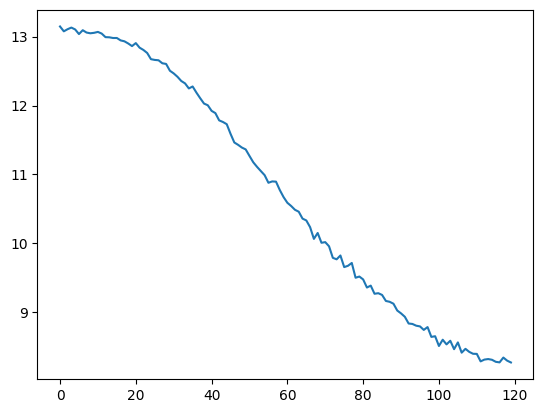

In [ ]:
BATCH_SIZE_ENC = 32
N_EPOCHS_ENC = 120

loader_train_enc = DataLoader(dataset_train, batch_size=BATCH_SIZE_ENC, shuffle=True, num_workers=2, pin_memory=True)
optimizer_enc = torch.optim.SGD(encoder.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
scheduler_enc = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_enc, T_max=N_EPOCHS_ENC + 20)

losses = []
for epoch in range(N_EPOCHS_ENC):
    encoder.train()
    epoch_loss = 0
    for i, (img, fmri) in enumerate(loader_train_enc):
        img, fmri = img.to(DEVICE), fmri.to(DEVICE)
        fmri_pred = encoder(img)
        loss = fmri_loss(fmri_pred, fmri)
        optimizer_enc.zero_grad()
        loss.backward()
        optimizer_enc.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(loader_train_enc)
    scheduler_enc.step()
    losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
      encoder.eval()
      with torch.no_grad():
        imgs_sample, fmris_sample = next(iter(DataLoader(dataset_train, batch_size=64, shuffle=False)))
        fmri_pred = encoder(imgs_sample.to(DEVICE)).cpu()
        cos_sim = F.cosine_similarity(fmri_pred, fmris_sample, dim=1).mean().item()
      encoder.train()
      print(f'  Epoch {epoch+1:3d}/{N_EPOCHS_ENC}, '
          f'Loss : {avg_loss:.4f}, '
          f'Cos sim : {cos_sim:.4f}, '
          f'LR : {scheduler_enc.get_last_lr()[0]:.6f}')

plt.plot(losses)
plt.show()


In [ ]:
print(f'fmri_train mean : {fmri_train.mean():.3f}')
print(f'fmri_train std  : {fmri_train.std():.3f}')
print(f'fmri_train max  : {fmri_train.max():.3f}')

fmri_train mean : 0.034
fmri_train std  : 3.815
fmri_train max  : 20.000


5. Training of the decoder

In [ ]:
#freeze the encoder
encoder.eval()
for p in encoder.parameters():
  p.requires_grad = False

BATCH_SUPERVISED = 36 # 60%
BATCH_UNLABELED = 12 # 20%
BATCH_FMRI = 12 # 20%
N_EPOCHS_DEC = 250

loader_supervised = DataLoader(dataset_train, batch_size=BATCH_SUPERVISED, shuffle=True, num_workers=2, pin_memory=True)
loader_unlabeled = DataLoader(dataset_unlabeled, batch_size=BATCH_UNLABELED, shuffle=True, num_workers=2, pin_memory=True)
loader_fmri = DataLoader(dataset_fmri_test, batch_size=BATCH_FMRI, shuffle=True, num_workers=2, pin_memory=True)

optimizer_dec = torch.optim.Adam(decoder.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_dec = torch.optim.lr_scheduler.StepLR(optimizer_dec, step_size=30, gamma=0.2)






In [ ]:
dec_losses = {'total': [], 'L_D': [], 'L_ED': [], 'L_DE': []}

def infinite_loader(loader):
    while True:
        for batch in loader:
            yield batch

iter_unlabeled = infinite_loader(loader_unlabeled)
iter_fmri_test = infinite_loader(loader_fmri)

for epoch in range(N_EPOCHS_DEC):
    decoder.train()
    epoch_total = 0
    epoch_ld = 0
    epoch_led = 0
    epoch_lde = 0
    n_steps = 0

    for imgs_sup, fmris_sup in loader_supervised:
        imgs_sup  = imgs_sup.to(DEVICE)
        fmris_sup = fmris_sup.to(DEVICE)

        # unlabeled data
        imgs_unlab = next(iter_unlabeled).to(DEVICE)

        # test fMRI
        fmris_test_batch = next(iter_fmri_test).to(DEVICE)

        optimizer_dec.zero_grad()

        # L_D : supervised loss
        recon_sup = decoder(fmris_sup)
        imgs_sup_01 = (imgs_sup * torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1).to(DEVICE)
                       + torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1).to(DEVICE)).clamp(0, 1)
        l_d = image_loss(recon_sup, imgs_sup_01)

        # L_ED : unlabeled loss image to image
        with torch.no_grad():
            fmri_pred_unlab = encoder(imgs_unlab)
        recon_unlab = decoder(fmri_pred_unlab)
        imgs_unlab_01 = (imgs_unlab * torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1).to(DEVICE)
                         + torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1).to(DEVICE)).clamp(0, 1)
        l_ed = image_loss(recon_unlab, imgs_unlab_01)

        # L_DE : unlabeled loss fMRI to fMRI
        recon_from_fmri = decoder(fmris_test_batch)
        with torch.no_grad():
            fmri_reencoded = encoder(recon_from_fmri)
        recon_from_fmri_2 = decoder(fmris_test_batch)
        fmri_reencoded_2  = encoder(recon_from_fmri_2)
        l_de = fmri_loss(fmri_reencoded_2, fmris_test_batch)

        #total loss
        lambda_d = 1
        lambda_ed = 1
        lambda_de = 0.1
        total_loss = lambda_d * l_d + lambda_ed * l_ed + lambda_de * l_de
        total_loss.backward()

        nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=1.0)
        optimizer_dec.step()

        epoch_total += total_loss.item()
        epoch_ld += l_d.item()
        epoch_led += l_ed.item()
        epoch_lde += l_de.item()
        n_steps += 1

    scheduler_dec.step()

    avg_total = epoch_total / n_steps
    dec_losses['total'].append(avg_total)
    dec_losses['L_D'].append(epoch_ld / n_steps)
    dec_losses['L_ED'].append(epoch_led / n_steps)
    dec_losses['L_DE'].append(epoch_lde / n_steps)

    if (epoch + 1) % 10 == 0:
        print(f'  Epoch {epoch+1:3d}/{N_EPOCHS_DEC} | Total={avg_total:.4f} '
              f'L_D={dec_losses["L_D"][-1]:.4f} '
              f'L_ED={dec_losses["L_ED"][-1]:.4f} '
              f'L_DE={dec_losses["L_DE"][-1]:.4f}')

  Epoch  10/250 | Total=0.9167 L_D=0.2648 L_ED=0.2118 L_DE=4.4011
  Epoch  20/250 | Total=0.8753 L_D=0.2454 L_ED=0.1925 L_DE=4.3750
  Epoch  30/250 | Total=0.8491 L_D=0.2366 L_ED=0.1877 L_DE=4.2472
  Epoch  40/250 | Total=0.8071 L_D=0.2123 L_ED=0.1742 L_DE=4.2056
  Epoch  50/250 | Total=0.8009 L_D=0.2060 L_ED=0.1717 L_DE=4.2325
  Epoch  60/250 | Total=0.7760 L_D=0.1984 L_ED=0.1651 L_DE=4.1253


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Decoder losses', fontsize=12)

axes[0].plot(dec_losses['total'], color='black', lw=1.5, label='Total')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss totale')
axes[0].grid(True, alpha=0.3)

axes[1].plot(dec_losses['L_D'],  color='steelblue',  lw=1.5, label='L_D (supervise)')
axes[1].plot(dec_losses['L_ED'], color='darkorange',  lw=1.5, label='L_ED (img non labelisees)')
axes[1].plot(dec_losses['L_DE'], color='forestgreen', lw=1.5, label='L_DE (fMRI test)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('loss components')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
encoder.eval()
decoder.eval()

N_SHOW = min(8, len(dataset_test_vis))
loader_vis = DataLoader(dataset_test_vis, batch_size=N_SHOW, shuffle=False)
imgs_gt, fmris_gt = next(iter(loader_vis))

with torch.no_grad():
    recon_from_fmri = decoder(fmris_gt.to(DEVICE)).cpu()
    fmri_encoded = encoder(imgs_gt.to(DEVICE)).cpu()
    recon_from_enc  = decoder(fmri_encoded.to(DEVICE)).cpu()

fig, axes = plt.subplots(3, N_SHOW, figsize=(N_SHOW * 2.5, 8))
fig.suptitle('Results', fontsize=11)

row_labels = ['Original image', 'Reconstruction (real fMRI)', 'Reconstruction (encoded fMRI)']
for r, label in enumerate(row_labels):
    axes[r, 0].set_ylabel(label, fontsize=8)

for c in range(N_SHOW):
    axes[0, c].imshow(denormalize(imgs_gt[c]).permute(1, 2, 0))
    axes[0, c].axis('off')

    axes[1, c].imshow(recon_from_fmri[c].permute(1, 2, 0).clamp(0, 1))
    axes[1, c].axis('off')

    axes[2, c].imshow(recon_from_enc[c].permute(1, 2, 0).clamp(0, 1))
    axes[2, c].axis('off')

plt.tight_layout()
plt.show()
